Loading libs and checking corrections

In [46]:
import pandas as pd
import sqlite3
import sqlalchemy
import matplotlib.pyplot as plt
from pathlib import Path
print("Libraries loaded successfully")
df = pd.read_csv("train.csv",encoding="latin1")

print(df.shape)
print(df.columns.tolist())

Libraries loaded successfully
(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
BASE_DIR = Path.cwd()

CSV_FILE = BASE_DIR / "train.csv"
DB_FILE = BASE_DIR / "superstore.db"

print("CSV:", CSV_FILE)
print("Database:", DB_FILE)
df = pd.read_csv(CSV_FILE)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
display(df.head())

CSV: c:\Users\G614JV\Desktop\sales an\train.csv
Database: c:\Users\G614JV\Desktop\sales an\superstore.db


Cleaning and coverting to datetime

In [47]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print(df.columns.tolist())
df["order_date"] = pd.to_datetime(df["order_date"]).dt.strftime("%Y-%m-%d")
df["ship_date"] = pd.to_datetime(df["ship_date"]).dt.strftime("%Y-%m-%d")

print(df[["order_date", "ship_date"]].head())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']
   order_date   ship_date
0  2016-11-08  2016-11-11
1  2016-11-08  2016-11-11
2  2016-06-12  2016-06-16
3  2015-10-11  2015-10-18
4  2015-10-11  2015-10-18


In [49]:
# DB creation and table configuration

import sqlite3

# Connect to the database
conn = sqlite3.connect(DB_FILE)

# Delete the old table if it already exists
conn.execute("DROP TABLE IF EXISTS orders")
conn.commit()

# Create a fresh orders table
create_table_sql = """
CREATE TABLE orders (
    row_id INTEGER,
    order_id TEXT,
    order_date DATE,
    ship_date DATE,
    ship_mode TEXT,
    customer_id TEXT,
    customer_name TEXT,
    segment TEXT,
    country TEXT,
    city TEXT,
    state TEXT,
    postal_code TEXT,
    region TEXT,
    product_id TEXT,
    category TEXT,
    sub_category TEXT,
    product_name TEXT,
    sales NUMERIC,
    quantity INTEGER,
    discount NUMERIC,
    profit NUMERIC
);
"""

conn.execute(create_table_sql)
conn.commit()

print("orders table created successfully.")

orders table created successfully.


In [50]:
# Load CSV data into the orders table

df.to_sql(
    "orders",
    conn,
    if_exists="append",
    index=False
)

print("CSV successfully loaded into orders.")

CSV successfully loaded into orders.


In [51]:
# Check number of rows

result = pd.read_sql(
    "SELECT COUNT(*) AS row_count FROM orders;",
    conn
)

display(result)

,row_count
0,9994


In [52]:
from sqlalchemy import create_engine

engine = create_engine(f"sqlite:///{DB_FILE}")

print("SQLAlchemy engine connected successfully.")

SQLAlchemy engine connected successfully.


In [53]:
q1 = """
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT customer_id) AS distinct_customers,
    COUNT(DISTINCT product_id) AS distinct_products,
    MIN(order_date) AS min_order_date,
    MAX(order_date) AS max_order_date
FROM orders;
"""

q1_result = pd.read_sql(q1, engine)

display(q1_result)

,row_count,distinct_customers,distinct_products,min_order_date,max_order_date
0,9994,793,1862,2014-01-03,2017-12-30


In [54]:
q2 = """
SELECT
    SUM(CASE WHEN row_id IS NULL THEN 1 ELSE 0 END) AS row_id_nulls,
    SUM(CASE WHEN order_id IS NULL THEN 1 ELSE 0 END) AS order_id_nulls,
    SUM(CASE WHEN order_date IS NULL THEN 1 ELSE 0 END) AS order_date_nulls,
    SUM(CASE WHEN ship_date IS NULL THEN 1 ELSE 0 END) AS ship_date_nulls,
    SUM(CASE WHEN ship_mode IS NULL THEN 1 ELSE 0 END) AS ship_mode_nulls,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS customer_id_nulls,
    SUM(CASE WHEN customer_name IS NULL THEN 1 ELSE 0 END) AS customer_name_nulls,
    SUM(CASE WHEN segment IS NULL THEN 1 ELSE 0 END) AS segment_nulls,
    SUM(CASE WHEN country IS NULL THEN 1 ELSE 0 END) AS country_nulls,
    SUM(CASE WHEN city IS NULL THEN 1 ELSE 0 END) AS city_nulls,
    SUM(CASE WHEN state IS NULL THEN 1 ELSE 0 END) AS state_nulls,
    SUM(CASE WHEN postal_code IS NULL THEN 1 ELSE 0 END) AS postal_code_nulls,
    SUM(CASE WHEN region IS NULL THEN 1 ELSE 0 END) AS region_nulls,
    SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) AS product_id_nulls,
    SUM(CASE WHEN category IS NULL THEN 1 ELSE 0 END) AS category_nulls,
    SUM(CASE WHEN sub_category IS NULL THEN 1 ELSE 0 END) AS sub_category_nulls,
    SUM(CASE WHEN product_name IS NULL THEN 1 ELSE 0 END) AS product_name_nulls,
    SUM(CASE WHEN sales IS NULL THEN 1 ELSE 0 END) AS sales_nulls,
    SUM(CASE WHEN quantity IS NULL THEN 1 ELSE 0 END) AS quantity_nulls,
    SUM(CASE WHEN discount IS NULL THEN 1 ELSE 0 END) AS discount_nulls,
    SUM(CASE WHEN profit IS NULL THEN 1 ELSE 0 END) AS profit_nulls
FROM orders;
"""

q2_result = pd.read_sql(q2, engine)

display(q2_result)

,row_id_nulls,order_id_nulls,order_date_nulls,ship_date_nulls,ship_mode_nulls,customer_id_nulls,customer_name_nulls,segment_nulls,country_nulls,city_nulls,...,postal_code_nulls,region_nulls,product_id_nulls,category_nulls,sub_category_nulls,product_name_nulls,sales_nulls,quantity_nulls,discount_nulls,profit_nulls
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
q3 = """
SELECT
    order_id,
    product_id,
    COUNT(*) AS duplicate_count
FROM orders
GROUP BY order_id, product_id
HAVING COUNT(*) > 1;
"""

q3_result = pd.read_sql(q3, engine)

display(q3_result)

,order_id,product_id,duplicate_count
0,CA-2015-103135,OFF-BI-10000069,2
1,CA-2016-129714,OFF-PA-10001970,2
2,CA-2016-137043,FUR-FU-10003664,2
3,CA-2016-140571,OFF-PA-10001954,2
4,CA-2017-118017,TEC-AC-10002006,2
5,CA-2017-152912,OFF-ST-10003208,2
6,US-2014-150119,FUR-CH-10002965,2
7,US-2016-123750,TEC-AC-10004659,2


In [56]:
q4 = """
SELECT
    ship_mode,
    ROUND(
        AVG(
            julianday(ship_date) - julianday(order_date)
        ),
        2
    ) AS avg_days_to_ship
FROM orders
GROUP BY ship_mode
ORDER BY avg_days_to_ship;
"""

q4_result = pd.read_sql(q4, engine)

display(q4_result)

,ship_mode,avg_days_to_ship
0,Same Day,0.04
1,First Class,2.18
2,Second Class,3.24
3,Standard Class,5.01


In [57]:
q5 = """
SELECT
    region,
    category,
    sub_category,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(
        SUM(profit) / NULLIF(SUM(sales), 0) * 100,
        2
    ) AS profit_margin_pct
FROM orders
GROUP BY
    region,
    category,
    sub_category
ORDER BY total_profit ASC;
"""

q5_result = pd.read_sql(q5, engine)

display(q5_result)

,region,category,sub_category,total_sales,total_profit,profit_margin_pct
0,East,Furniture,Tables,39139.81,-11025.38,-28.17
1,South,Furniture,Tables,43916.19,-4623.06,-10.53
2,Central,Furniture,Furnishings,15254.37,-3906.22,-25.61
3,Central,Furniture,Tables,39154.97,-3559.65,-9.09
4,Central,Office Supplies,Appliances,23582.03,-2638.62,-11.19
...,...,...,...,...,...,...
63,Central,Technology,Copiers,37259.57,15608.84,41.89
64,West,Office Supplies,Binders,55961.11,16096.80,28.76
65,West,Technology,Accessories,61114.12,16484.60,26.97
66,East,Technology,Copiers,53219.46,17022.84,31.99


In [58]:
q6 = """
WITH subcategory_profit AS (
    SELECT
        sub_category,
        SUM(profit) AS total_profit
    FROM orders
    GROUP BY sub_category
),

ranked AS (
    SELECT
        sub_category,
        total_profit,
        RANK() OVER (
            ORDER BY total_profit DESC
        ) AS top_rank,
        RANK() OVER (
            ORDER BY total_profit ASC
        ) AS bottom_rank
    FROM subcategory_profit
)

SELECT
    'Top 5' AS ranking_group,
    sub_category,
    ROUND(total_profit, 2) AS total_profit,
    top_rank AS rank
FROM ranked
WHERE top_rank <= 5

UNION ALL

SELECT
    'Bottom 5' AS ranking_group,
    sub_category,
    ROUND(total_profit, 2) AS total_profit,
    bottom_rank AS rank
FROM ranked
WHERE bottom_rank <= 5

ORDER BY ranking_group, rank;
"""

q6_result = pd.read_sql(q6, engine)

display(q6_result)

,ranking_group,sub_category,total_profit,rank
0,Bottom 5,Tables,-17725.48,1
1,Bottom 5,Bookcases,-3472.56,2
2,Bottom 5,Supplies,-1189.10,3
3,Bottom 5,Fasteners,949.52,4
4,Bottom 5,Machines,3384.76,5
5,Top 5,Copiers,55617.82,1
6,Top 5,Phones,44515.73,2
7,Top 5,Accessories,41936.64,3
8,Top 5,Paper,34053.57,4
9,Top 5,Binders,30221.76,5


In [59]:
q7 = """
WITH discount_bands AS (
    SELECT
        CASE
            WHEN discount = 0 THEN '0%'
            WHEN discount > 0 AND discount <= 0.20 THEN '1-20%'
            WHEN discount > 0.20 AND discount <= 0.40 THEN '21-40%'
            ELSE '41%+'
        END AS discount_band,
        order_id,
        profit
    FROM orders
)

SELECT
    discount_band,
    COUNT(DISTINCT order_id) AS order_count,
    ROUND(AVG(profit), 2) AS avg_profit,
    ROUND(SUM(profit), 2) AS total_profit
FROM discount_bands
GROUP BY discount_band
ORDER BY
    CASE discount_band
        WHEN '0%' THEN 1
        WHEN '1-20%' THEN 2
        WHEN '21-40%' THEN 3
        WHEN '41%+' THEN 4
    END;
"""

q7_result = pd.read_sql(q7, engine)

display(q7_result)

,discount_band,order_count,avg_profit,total_profit
0,0%,2644,66.90,320987.60
1,1-20%,2507,26.50,100785.47
2,21-40%,400,-77.86,-35817.47
3,41%+,737,-106.71,-99558.59


In [60]:
q8 = """
WITH yearly_sales AS (
    SELECT
        CAST(strftime('%Y', order_date) AS INTEGER) AS order_year,
        SUM(sales) AS total_sales
    FROM orders
    GROUP BY
        CAST(strftime('%Y', order_date) AS INTEGER)
),

with_previous AS (
    SELECT
        order_year,
        total_sales,
        LAG(total_sales) OVER (
            ORDER BY order_year
        ) AS previous_year_sales
    FROM yearly_sales
)

SELECT
    order_year,
    ROUND(total_sales, 2) AS total_sales,
    ROUND(
        total_sales - previous_year_sales,
        2
    ) AS yoy_change,
    ROUND(
        (total_sales - previous_year_sales)
        / NULLIF(previous_year_sales, 0) * 100,
        2
    ) AS yoy_change_pct
FROM with_previous
ORDER BY order_year;
"""

q8_result = pd.read_sql(q8, engine)

display(q8_result)

,order_year,total_sales,yoy_change,yoy_change_pct
0,2014,484247.50,NaN,NaN
1,2015,470532.51,-13714.99,-2.83
2,2016,609205.60,138673.09,29.47
3,2017,733215.26,124009.66,20.36


In [61]:
q9 = """
WITH subcategory_summary AS (
    SELECT
        sub_category,
        SUM(sales) AS total_sales,
        SUM(profit) AS total_profit
    FROM orders
    GROUP BY sub_category
),

total_revenue AS (
    SELECT
        SUM(sales) AS company_sales
    FROM orders
)

SELECT
    s.sub_category,
    ROUND(s.total_sales, 2) AS total_sales,
    ROUND(s.total_profit, 2) AS total_profit,
    ROUND(
        s.total_sales / NULLIF(t.company_sales, 0) * 100,
        2
    ) AS revenue_share_pct
FROM subcategory_summary s
CROSS JOIN total_revenue t
WHERE s.total_profit < 0
ORDER BY s.total_profit ASC;
"""

q9_result = pd.read_sql(q9, engine)

display(q9_result)

,sub_category,total_sales,total_profit,revenue_share_pct
0,Tables,206965.53,-17725.48,9.01
1,Bookcases,114880.00,-3472.56,5.00
2,Supplies,46673.54,-1189.10,2.03


In [62]:
q10 = """
SELECT
    customer_id,
    customer_name,
    COUNT(DISTINCT order_id) AS order_count,
    ROUND(SUM(sales), 2) AS lifetime_sales,
    ROUND(SUM(profit), 2) AS lifetime_profit,
    ROUND(
        SUM(sales) / NULLIF(COUNT(DISTINCT order_id), 0),
        2
    ) AS average_order_value
FROM orders
GROUP BY
    customer_id,
    customer_name
ORDER BY lifetime_profit DESC
LIMIT 10;
"""

q10_result = pd.read_sql(q10, engine)

display(q10_result)

,customer_id,customer_name,order_count,lifetime_sales,lifetime_profit,average_order_value
0,TC-20980,Tamara Chand,5,19052.22,8981.32,3810.44
1,RB-19360,Raymond Buch,6,15117.34,6976.10,2519.56
2,SC-20095,Sanjit Chand,9,14142.33,5757.41,1571.37
3,HL-15040,Hunter Lopez,6,12873.30,5622.43,2145.55
4,AB-10105,Adrian Barton,10,14473.57,5444.81,1447.36
5,TA-21385,Tom Ashbrook,4,14595.62,4703.79,3648.91
6,CM-12385,Christopher Martinez,4,8954.02,3899.89,2238.51
7,KD-16495,Keith Dawkins,12,8181.26,3038.63,681.77
8,AR-10540,Andy Reiter,6,6608.45,2884.62,1101.41
9,DR-12940,Daniel Raglin,8,8350.87,2869.08,1043.86


In [63]:
# Chart 1: Profit by Sub-Category

profit_by_subcategory = pd.read_sql(
    """
    SELECT
        sub_category,
        ROUND(SUM(profit), 2) AS total_profit
    FROM orders
    GROUP BY sub_category
    ORDER BY total_profit;
    """,
    engine
)

display(profit_by_subcategory)

,sub_category,total_profit
0,Tables,-17725.48
1,Bookcases,-3472.56
2,Supplies,-1189.10
3,Fasteners,949.52
4,Machines,3384.76
5,Labels,5546.25
6,Art,6527.79
7,Envelopes,6964.18
8,Furnishings,13059.14
9,Appliances,18138.01


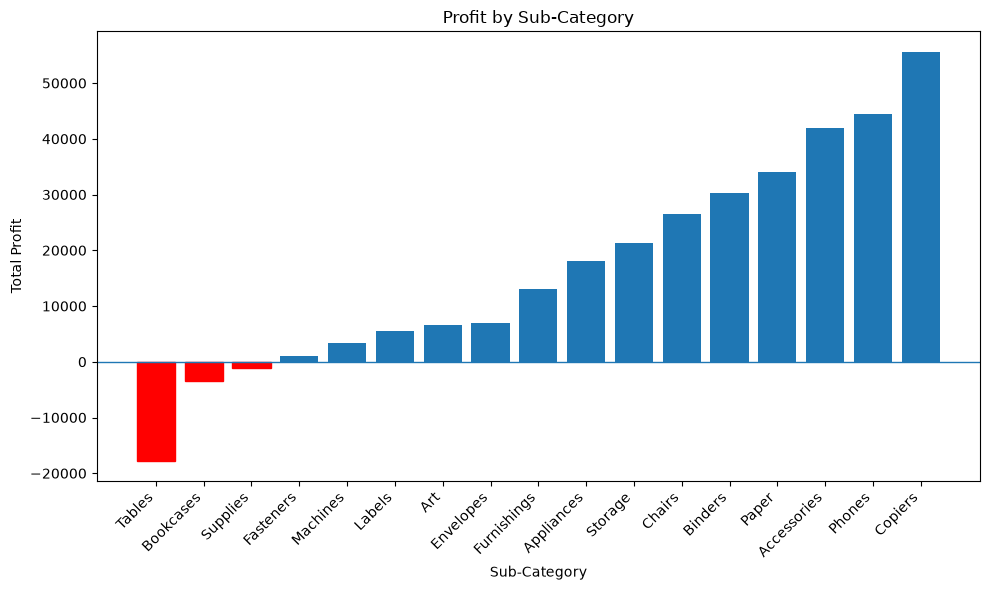

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    profit_by_subcategory["sub_category"],
    profit_by_subcategory["total_profit"]
)

# Highlight loss-making sub-categories
for bar, value in zip(
    bars,
    profit_by_subcategory["total_profit"]
):
    if value < 0:
        bar.set_color("red")

plt.axhline(0, linewidth=1)
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [65]:
# Chart 2: Average Profit by Discount Band

discount_chart = pd.read_sql(
    """
    WITH discount_bands AS (
        SELECT
            CASE
                WHEN discount = 0 THEN '0%'
                WHEN discount > 0 AND discount <= 0.20 THEN '1-20%'
                WHEN discount > 0.20 AND discount <= 0.40 THEN '21-40%'
                ELSE '41%+'
            END AS discount_band,
            profit
        FROM orders
    )

    SELECT
        discount_band,
        ROUND(AVG(profit), 2) AS avg_profit
    FROM discount_bands
    GROUP BY discount_band
    ORDER BY
        CASE discount_band
            WHEN '0%' THEN 1
            WHEN '1-20%' THEN 2
            WHEN '21-40%' THEN 3
            WHEN '41%+' THEN 4
        END;
    """,
    engine
)

display(discount_chart)

,discount_band,avg_profit
0,0%,66.90
1,1-20%,26.50
2,21-40%,-77.86
3,41%+,-106.71


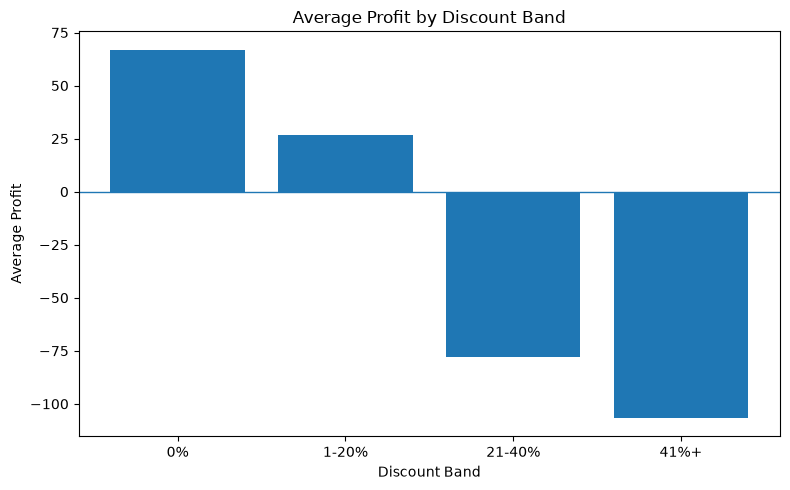

In [66]:
plt.figure(figsize=(8, 5))

plt.bar(
    discount_chart["discount_band"],
    discount_chart["avg_profit"]
)

plt.axhline(0, linewidth=1)
plt.title("Average Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.show()

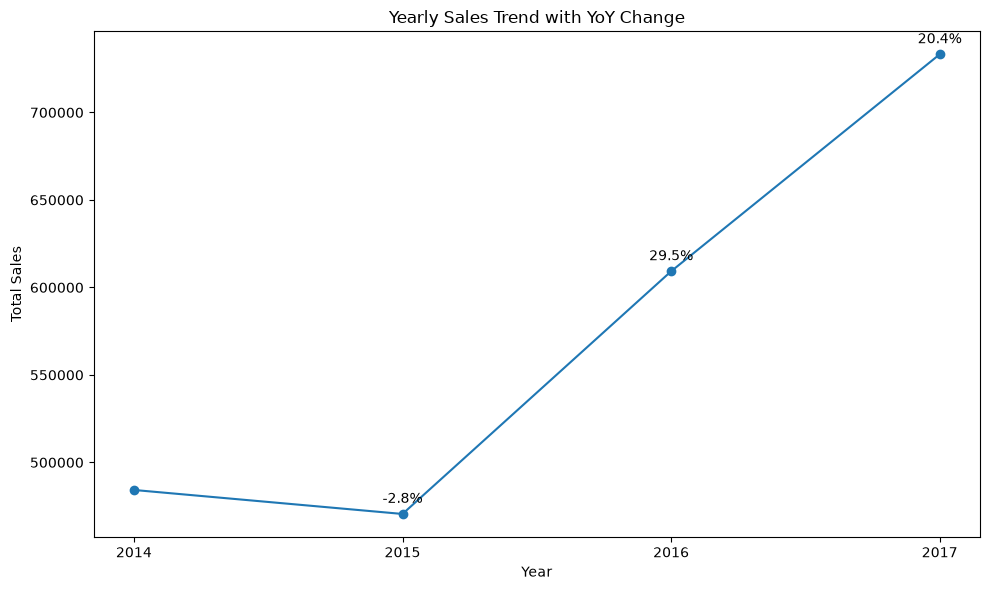

In [67]:
# Chart 3: Yearly Sales Trend

plt.figure(figsize=(10, 6))

plt.plot(
    q8_result["order_year"],
    q8_result["total_sales"],
    marker="o"
)

# Add YoY percentage labels
for _, row in q8_result.iterrows():
    if pd.notna(row["yoy_change_pct"]):
        plt.annotate(
            f'{row["yoy_change_pct"]:.1f}%',
            (row["order_year"], row["total_sales"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center"
        )

plt.title("Yearly Sales Trend with YoY Change")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(q8_result["order_year"])
plt.tight_layout()
plt.show()